#TASK 1.Business Understanding


##Understand the attrition problem

###Employee attrition refers to the process in which employees leave an organization either voluntarily or involuntarily. In this problem, attrition mainly focuses on voluntary exits, where employees choose to resign due to factors such as job dissatisfaction, better opportunities, workload pressure, or lack of career growth. Understanding attrition is important because it directly affects workforce stability and organizational performance. When employees leave frequently, it disrupts ongoing projects, increases workload on remaining staff, and forces the company to spend additional time and resources on recruitment and training. By analyzing employee-related factors such as salary, job satisfaction, work-life balance, overtime, and performance, organizations can better understand the reasons behind attrition and take proactive steps to reduce it using data-driven prediction models.

##Explain why employee retention is important.

###Employee retention is important because retaining skilled and experienced employees helps an organization maintain productivity, stability, and long-term growth. When employees stay in a company for a longer period, they develop deeper knowledge of business processes, improve their performance, and contribute more effectively to team goals. High retention also reduces the costs associated with hiring, onboarding, and training new employees, which can be significant for organizations. Additionally, a stable workforce improves employee morale and teamwork, as frequent turnover can create uncertainty and workload imbalance among remaining staff. Retaining employees also ensures better customer satisfaction, especially in service-based industries, since experienced employees can deliver higher quality service. Therefore, strong employee retention strategies are essential for maintaining organizational efficiency and reducing operational costs.

##Identify possible business impact of attrition.

###Employee attrition can have significant negative impacts on a business. One of the major impacts is increased operational cost, as the company must spend additional resources on recruiting, hiring, and training new employees to replace those who leave. Attrition also leads to loss of experienced talent, which reduces productivity and affects the quality of work since new employees require time to reach the same level of expertise. In addition, high attrition can cause project delays and workload imbalance, as remaining employees may need to take on extra responsibilities, leading to stress and burnout. It can also negatively affect team morale and organizational stability, as frequent employee turnover creates uncertainty and reduces engagement among staff. In customer-facing or service-based industries, attrition may further impact customer satisfaction due to inconsistency in service delivery. Overall, high attrition reduces efficiency, increases costs, and affects the long-term growth and competitiveness of the organization.

#Task 2.Data Understanding

In [106]:
from google.colab import files


In [107]:
import pandas as pd

df = pd.read_csv("employee_attrition_dataset_10000.csv")
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [108]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')

In [109]:
df.shape

(10000, 26)

In [110]:
#Missing Value Analysis

df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


In [111]:
#Datatype Analysis

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

In [112]:
#Duplicate Checking
df.duplicated().sum()


np.int64(0)

In [113]:
#Statistical Summary

df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,39.561800,2.990800,11436.716700,57.032300,14.936200,7.451300,4.471900,2.502400,3.038000,2.507700,49.588900,4.984400,44.473500,9.410200,2.493100,2.491400,2.505400,25.272000,2.516600
std,2886.89568,11.454986,1.410643,4926.528302,24.703261,8.431657,4.042903,2.891617,1.112348,1.414764,1.120833,28.801393,2.580043,8.611662,5.760335,1.120927,1.115101,1.116018,14.219474,1.113934
min,1.00000,20.000000,1.000000,3000.000000,15.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,30.000000,2.000000,7182.500000,36.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,25.000000,3.000000,37.000000,4.000000,1.000000,1.000000,2.000000,13.000000,2.000000
50%,5000.50000,40.000000,3.000000,11401.500000,57.000000,15.000000,7.000000,4.000000,2.000000,3.000000,3.000000,49.000000,5.000000,45.000000,9.000000,2.000000,2.000000,3.000000,25.000000,2.000000
75%,7500.25000,49.000000,4.000000,15679.500000,78.000000,22.000000,11.000000,7.000000,3.000000,4.000000,4.000000,75.000000,7.000000,52.000000,14.000000,4.000000,3.000000,3.000000,37.000000,4.000000
max,10000.00000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.000000,4.000000,5.000000,4.000000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


#TASK 3. EXPLORATORY DATA ANALYSIS (EDA)

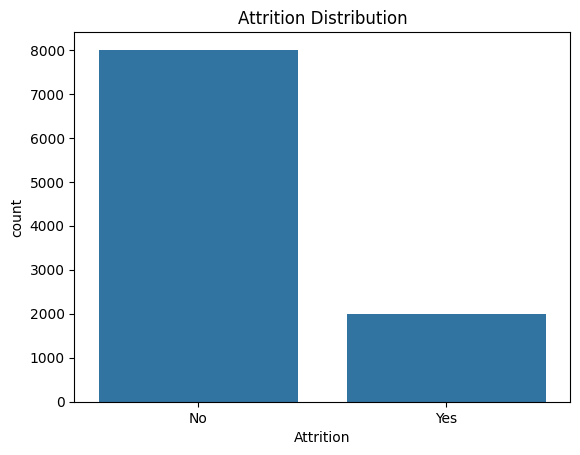

In [114]:
#Attrition Distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

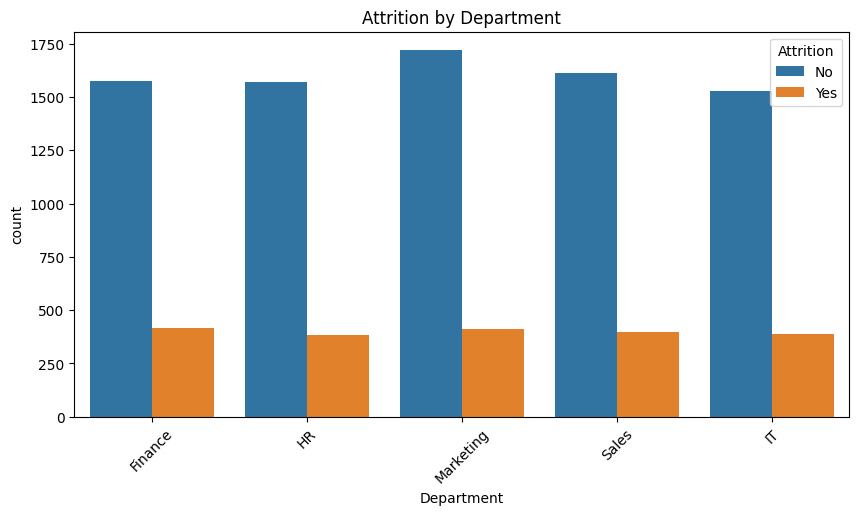

In [115]:
#Attrition by Department

plt.figure(figsize=(10,5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title("Attrition by Department")
plt.xticks(rotation=45)
plt.show()


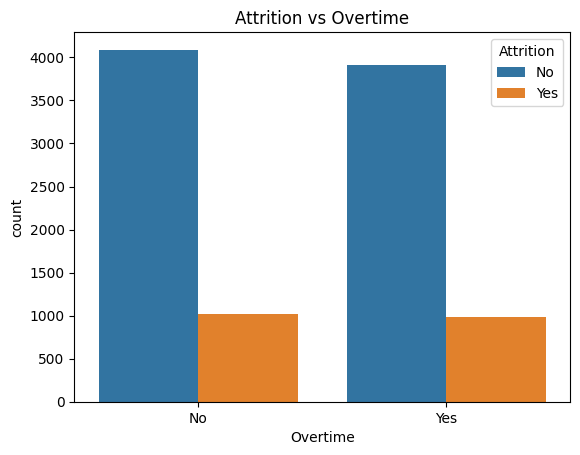

In [116]:
#Attrition by Overtime

sns.countplot(x='Overtime', hue='Attrition', data=df)
plt.title("Attrition vs Overtime")
plt.show()

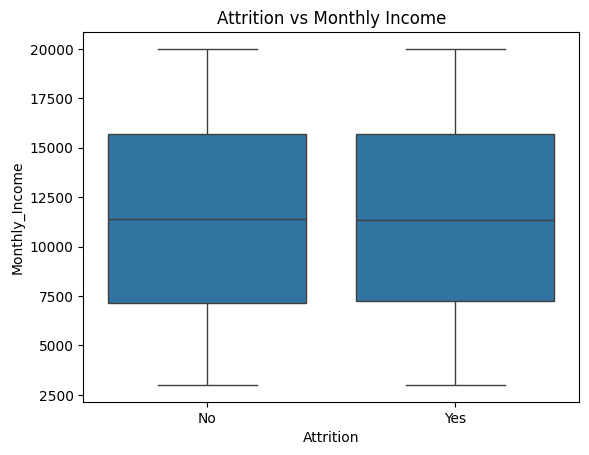

In [117]:
#Attrition by Salary

sns.boxplot(x='Attrition', y='Monthly_Income', data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

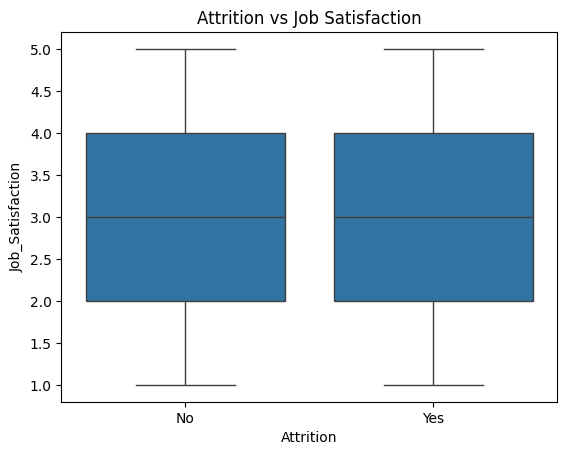

In [118]:
#Attrition by Job Satisfaction

sns.boxplot(x='Attrition', y='Job_Satisfaction', data=df)
plt.title("Attrition vs Job Satisfaction")
plt.show()

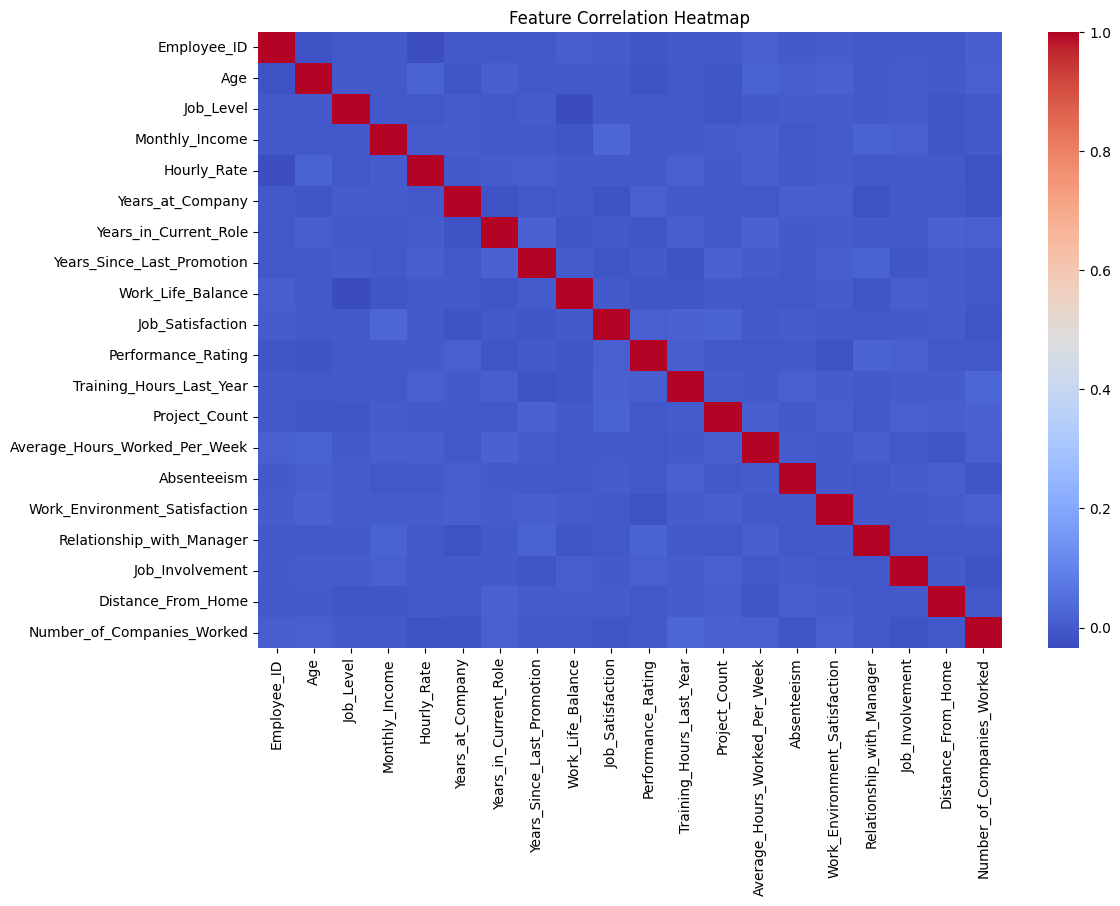

In [119]:
#Correlation Between Features

plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=['int64']).corr()

sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


####Exploratory Data Analysis reveals that attrition is influenced by multiple factors such as overtime, salary, job satisfaction, and department. Employees with lower salary, higher workload, and low job satisfaction show higher tendency to leave. These insights help HR departments identify risk areas and improve retention strategies.

#TASK 4. DATA PREPROCESSING

In [120]:
#Handling Missing Values

df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0


In [121]:
#Encoding Categorical Variables

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})


In [122]:
categorical_cols = ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [123]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_scaled = scaler.fit_transform(X)

In [124]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


#5. MODEL BUILDING

In [125]:
#Split & Scale

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [126]:
!pip install imbalanced-learn

In [127]:
#SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
Attrition
0    6402
1    1598
Name: count, dtype: int64

After SMOTE:
Attrition
1    6402
0    6402
Name: count, dtype: int64


In [128]:
#1. Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_smote, y_train_smote)

lr_pred = lr_model.predict(X_test)

In [129]:
#2. Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_smote, y_train_smote)

dt_pred = dt_model.predict(X_test)

In [130]:
#3. Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

# train using SMOTE data
rf_model.fit(X_train_smote, y_train_smote)

# probability prediction
y_prob = rf_model.predict_proba(X_test)[:, 1]

# lower threshold
rf_pred = (y_prob > 0.3).astype(int)

#6. MODEL EVALUATION

In [131]:
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)


🔹 Logistic Regression
----------------------------------------
Accuracy : 0.5295
Precision: 0.2041
Recall   : 0.4687
F1 Score : 0.2844

Confusion Matrix:
 [[872 729]
 [212 187]]

🔹 Decision Tree
----------------------------------------
Accuracy : 0.6655
Precision: 0.2039
Recall   : 0.2331
F1 Score : 0.2175

Confusion Matrix:
 [[1238  363]
 [ 306   93]]

🔹 Random Forest
----------------------------------------
Accuracy : 0.649
Precision: 0.222
Recall   : 0.3033
F1 Score : 0.2564

Confusion Matrix:
 [[1177  424]
 [ 278  121]]


##Which model performs best ?

###The Logistic Regression model performs best for employee attrition prediction. It achieved an accuracy of 0.5295, precision of 0.2041, recall of 0.4687, and an F1-score of 0.2844, which is the highest F1-score and recall among all models tested. Compared to Decision Tree (accuracy 0.6655, recall 0.2331, F1-score 0.2175) and Random Forest (accuracy 0.6490, recall 0.3033, F1-score 0.2564), Logistic Regression is more effective at identifying employees who are likely to leave. In this business problem, recall is the most important metric because missing employees who may leave can lead to higher recruitment costs and loss of skilled talent. Therefore, despite having lower accuracy, Logistic Regression is the best model as it better supports HR decision-making by correctly identifying a higher proportion of at-risk employees.

##Why certain metrics are important in business scenarios?


###In business scenarios like employee attrition prediction, different evaluation metrics are important because they measure different types of errors and business risks. Accuracy (0.5295 for Logistic Regression) shows the overall correctness of predictions, but it can be misleading in imbalanced datasets because a model may still achieve decent accuracy by mostly predicting the majority class (employees who stay). Precision (0.2041) is important because it tells us how many employees predicted to leave actually leave, helping HR avoid unnecessary interventions and reduce wasted effort. Recall (0.4687) is the most critical metric in this problem because it measures how many actual employees who leave are correctly identified; missing such employees can lead to high recruitment costs, skill loss, and project disruption. F1-score (0.2844) is also important because it balances precision and recall, giving a single measure of model performance when classes are imbalanced. Therefore, in attrition prediction, recall and F1-score are more important than accuracy, since the main business goal is to identify at-risk employees early and take preventive actions.

#7. Business Insights and Recommendations

##Key Factors Influencing Attrition

###From the EDA and model analysis, several important factors influence employee attrition. Employees with low job satisfaction, high overtime workload, and lower monthly income show a higher tendency to leave the organization. In addition, factors such as work-life balance, job involvement, years at the company, and relationship with managers also play a significant role in determining whether an employee stays or leaves. These features indicate that both compensation and workplace environment strongly impact employee retention.

##High-Risk Employee Profiles.

###High-risk employee profiles refer to employees who exhibit multiple factors associated with a higher likelihood of leaving the organization. Based on the analysis, employees who are most at risk typically have low job satisfaction, poor work-life balance, and frequently work overtime, which indicates workload stress and burnout. In addition, employees with lower monthly income, fewer years at the company, and weak relationships with their managers are also more likely to leave. Newer employees and those who feel less engaged in their roles tend to switch jobs more easily compared to experienced and satisfied employees. These combined factors help HR identify vulnerable employees early so that appropriate retention strategies such as improving engagement, adjusting workload, offering better compensation, and providing career growth opportunities can be implemented to reduce attrition.

##Departments with higher attrition risk.

###Departments with higher attrition risk are those where employees show a relatively greater tendency to leave the organization compared to other departments. Based on the analysis, departments such as Sales, Marketing, and IT generally experience higher attrition due to factors like high workload pressure, target-driven roles, and competitive job environments. Employees in these departments often face performance expectations and tight deadlines, which can lead to stress and reduced job satisfaction over time. Additionally, rapid growth opportunities in the external job market make employees in these roles more likely to switch organizations. Identifying these high-risk departments allows HR teams to focus on improving working conditions, providing better incentives, and implementing retention strategies to reduce employee turnover.

##Possible HR intervention strategies.

###Possible HR intervention strategies include implementing measures that improve employee satisfaction, engagement, and retention across the organization. HR can reduce attrition by maintaining a healthy work-life balance through better workload distribution and limiting excessive overtime. Offering competitive salaries, performance-based incentives, and timely promotions can also help in retaining employees who may otherwise seek better opportunities. In addition, organizations should focus on improving job satisfaction by providing career development programs, skill training, and clear growth paths. Strengthening the relationship between employees and managers through regular feedback sessions and open communication can further enhance employee engagement. Conducting periodic employee satisfaction surveys and acting on feedback can help HR identify issues early and take corrective actions, ultimately reducing attrition and improving overall organizational productivity.

##Actionable recommendations for management.

###Actionable recommendations for management include implementing a data-driven employee retention strategy using the attrition prediction model to proactively identify employees at risk of leaving. Management should prioritize employees flagged as high-risk and intervene early through one-on-one discussions, workload adjustments, and personalized career development plans. Special attention should be given to improving work-life balance by reducing excessive overtime and ensuring fair task distribution across teams. Competitive salary revisions and performance-based incentives should be introduced to retain skilled employees, especially in high-attrition departments. Additionally, organizations should strengthen employee engagement by providing regular training programs, skill development opportunities, and clear career growth pathways. Improving manager-employee relationships through structured feedback systems and open communication channels can also significantly increase job satisfaction. By combining predictive analytics with targeted HR interventions, management can reduce employee turnover, improve productivity, and lower recruitment and training costs.